# 📝 Student Notes: ArUco & AprilTags

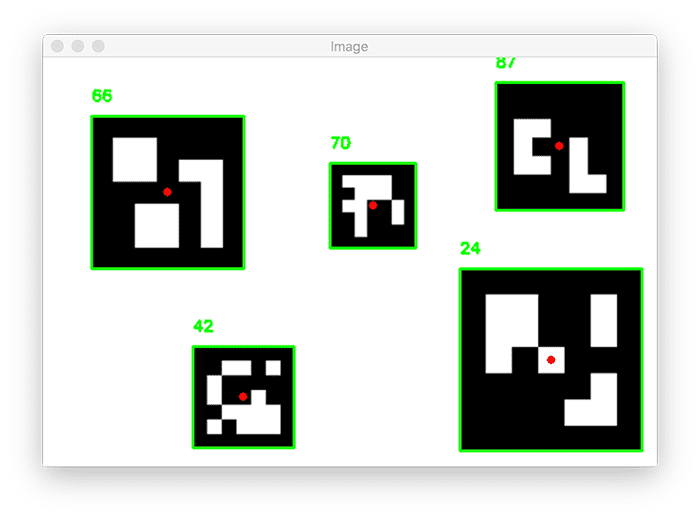

### 1. What are they? (The "3D Anchor")
*   **Definition:** They are **fiducial markers**—physical, black-and-white square stickers that act as "landing pads" for computer vision.
*   **The Look:** A thick black outer border with a unique internal grid of black (0) and white (1) squares.
*   **Purpose:** They allow a camera to identify a specific **ID** and calculate its exact **3D Position** (distance and angle).

---

### 2. How it Works (The "Math")
1.  **Detection:** The computer scans for the high-contrast square black border.
2.  **Identification:** It reads the inner grid like a **binary code** to see which ID it is (e.g., "Marker #42").
3.  **Pose Estimation:** By looking at how the corners are "warped" or tilted, the computer calculates:
    *   **Translation ($tvec$):** How far away is it? (X, Y, Z coordinates).
    *   **Rotation ($rvec$):** At what angle is it tilted?

---

### 3. ArUco vs. AprilTag (Quick Comparison)


| Feature | **ArUco** | **AprilTag** |
| :--- | :--- | :--- |
| **Speed** | ⚡ Very Fast | 🐢 Slightly Slower |
| **Precision** | ✅ Good | 🎯 High (Less "Jitter") |
| **Setup** | Built into OpenCV (Easy) | Industrial Standard |
| **Best For** | AR Games, Beginners, Drones | Warehouse Robots, Factories |

---

### 4. Real-World Examples
*   **Furniture AR:** Tape a marker to the floor; your phone "snaps" a virtual 3D couch onto that spot.
*   **Warehouse Robots:** AprilTags on the floor tell a robot exactly which aisle it's in so it doesn't hit a shelf.
*   **Drone Landing:** A drone sees an ArUco marker on a landing pad and centers itself perfectly for a touch-down.

---

### 5. Pro-Tips for Success
*   **Matte over Glossy:** Never use shiny paper. Reflections (glare) "blind" the camera.
*   **Flatness:** Keep the marker on a flat surface. If the paper curls, the 3D math breaks.
*   **White Space:** Always leave a small white border around the black square so the camera can "see" the edge.

---

### 6. Key Vocabulary
*   **Dictionary:** A "family" of markers (e.g., `4x4_50` = 4x4 grid, 50 unique IDs).
*   **Library:** The software used to read them (usually **OpenCV** for Python/C++).
*   **Binary Matrix:** The 1s and 0s inside the square that form the ID.


In [4]:
!pip install opencv-contrib-python


KeyboardInterrupt: 

In [2]:
import cv2
import numpy as np
from google.colab.output import eval_js
from base64 import b64decode

def take_photo(quality=0.8):
  js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      // Resize the output to fit the video element.
      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

      // Wait for a click to capture
      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;

      // We will wait for a "capture" signal here
      await new Promise((resolve) => setTimeout(resolve, 500));
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getVideoTracks()[0].stop();
      div.remove();
      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
  display(js)
  data = eval_js('takePhoto({})'.format(quality))
  binary = b64decode(data.split(',')[1])

  # Convert to OpenCV format
  image = cv2.imdecode(np.frombuffer(binary, dtype=np.uint8), -1)
  return image


In [7]:
from google.colab.patches import cv2_imshow # Use this instead of cv2.imshow
from IPython.display import display, Javascript

# 1. Setup ArUco for 7x7
aruco_dict = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_7X7_250)
parameters = cv2.aruco.DetectorParameters()

try:
    # Capture frame from local webcam via JS
    frame = take_photo()

    # 2. Process with ArUco
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    corners, ids, _ = cv2.aruco.detectMarkers(gray, aruco_dict, parameters=parameters)

    if ids is not None:
        cv2.aruco.drawDetectedMarkers(frame, corners, ids)
        print(f"Detected Marker IDs: {ids.flatten()}")
    else:
        print("No marker found. Ensure the phone screen is bright!")

    # 3. Display in Colab
    cv2_imshow(frame)

except Exception as err:
    print(str(err))


<IPython.core.display.Javascript object>

KeyboardInterrupt: 

In [3]:
!sudo usermod -aG video $USER

Usage: usermod [options] LOGIN

Options:
  -b, --badnames                allow bad names
  -c, --comment COMMENT         new value of the GECOS field
  -d, --home HOME_DIR           new home directory for the user account
  -e, --expiredate EXPIRE_DATE  set account expiration date to EXPIRE_DATE
  -f, --inactive INACTIVE       set password inactive after expiration
                                to INACTIVE
  -g, --gid GROUP               force use GROUP as new primary group
  -G, --groups GROUPS           new list of supplementary GROUPS
  -a, --append                  append the user to the supplemental GROUPS
                                mentioned by the -G option without removing
                                the user from other groups
  -h, --help                    display this help message and exit
  -l, --login NEW_LOGIN         new value of the login name
  -L, --lock                    lock the user account
  -m, --move-home               move contents of the home direc

In [ ]:
import cv2
import numpy as np
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
from google.colab.patches import cv2_imshow

# 1. FUNCTION TO CAPTURE IMAGE FROM YOUR LOCAL WEBCAM
def take_photo(filename='photo.jpg', quality=0.8):
  js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = 'Capture';
      div.appendChild(capture);

      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      // Resize the output to fit the video element.
      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

      // Wait for Capture to be clicked.
      await new Promise((resolve) => capture.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getVideoTracks()[0].stop();
      div.remove();
      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
  display(js)
  data = eval_js('takePhoto({})'.format(quality))
  binary = b64decode(data.split(','))

  # Convert to OpenCV image
  image = cv2.imdecode(np.frombuffer(binary, dtype=np.uint8), -1)
  return image

# 2. RUN THE ARUCO DETECTION
try:
    print("Click the 'Capture' button that appears below to take a photo of your phone's marker.")
    img = take_photo()

    # Setup ArUco for 7x7
    aruco_dict = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_7X7_250)
    parameters = cv2.aruco.DetectorParameters()

    # Detect
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    corners, ids, _ = cv2.aruco.detectMarkers(gray, aruco_dict, parameters=parameters)

    if ids is not None:
        # Draw detected marker outlines
        cv2.aruco.drawDetectedMarkers(img, corners, ids)
        print(f"✅ Success! Detected Marker ID: {ids.flatten()}")
    else:
        print("❌ No marker found. Make sure the phone brightness is high and the border is visible.")

    # Show the result in Colab
    cv2_imshow(img)

except Exception as err:
    print(f"Error: {str(err)}")


Click the 'Capture' button that appears below to take a photo of your phone's marker.


<IPython.core.display.Javascript object>